In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import seaborn as sns
import numpy as np


In [3]:
data_path_events = Path("events_processed")
events_process_data = pd.concat(pd.read_parquet(par_file) for par_file in data_path_events.glob('*.parquet'))


In [4]:
data_path_framessync = Path('2022')
frames_sync_data = pd.concat(pd.read_parquet(par_file) for par_file in data_path_framessync.glob('*.parquet'))

In [5]:
events_data_pass = events_process_data[(events_process_data["end_x"] > 70) & (events_process_data['type'] == "pass")]
frames_sync_data = frames_sync_data[frames_sync_data['team_id'] != -1]

Analysis on similar frame in event and tracking data

In [6]:
def extract_same_frameid(event_df1,frames_df2):
    merge_df = pd.merge(event_df1, frames_df2[['id']], on='id', how='inner')
    df_events_filtered = event_df1[event_df1['id'].isin(merge_df['id'])]
    df_frames_filtered = frames_df2[frames_df2['id'].isin(merge_df['id'])]
    return df_events_filtered,df_frames_filtered

In [7]:
events_pass_new,frames_new = extract_same_frameid(events_data_pass,frames_sync_data)
events_pass_new = events_pass_new.reset_index(drop=True)
frames_new = frames_new.reset_index(drop=True)

In [92]:
events_pass_new.shape

(65880, 174)

In [93]:
events_data_pass.shape

(65919, 174)

In [7]:
frames_new_test = frames_new[frames_new['id'] == 1433018919 ]

In [54]:
frames_new_test

,team_id,team,jersey_number,player,role,speed,x_signality,y_signality,vx_signality,vy_signality,...,pitch_width,team_direction,id,frame,minute,second,period,start_frame,player_id_event,possession_team_id
161397,6716,away_team,20,Zachary Elbouzedi,0,0.072,0.85,34.84,0.020635,0.011111,...,68,right,1433018919,62268,86,37,2,62268.488281,51534,6713


In [8]:
frames_player_count = frames_new.groupby('id')['player'].count()
print(frames_player_count)

id
1238995789    22
1238995794    22
1238995795    22
1238995797    22
1238995799    22
              ..
1462655628    22
1462655629    21
1462655630    22
1462655633    22
1462655655    22
Name: player, Length: 65880, dtype: int64


In [9]:
frames_player_count.value_counts()

22    53110
21     9698
20     2063
19      525
18      233
17      106
16       43
15       25
14       21
4         9
12        8
7         6
10        6
9         5
8         4
11        4
13        4
2         3
6         3
3         2
1         1
5         1
Name: player, dtype: int64

In [10]:
missing_counts = frames_player_count.value_counts().reindex(range(1, 23), fill_value=0)


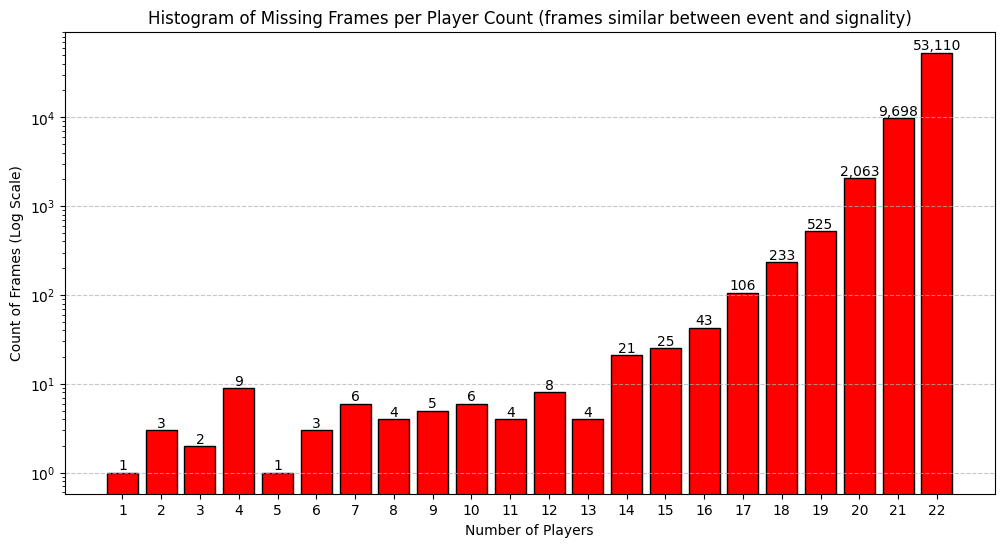

In [11]:
import matplotlib.pyplot as plt

# Create the bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(missing_counts.index, missing_counts.values, color='red', edgecolor='black')

# Add labels on top of bars
for bar in bars:
    height = bar.get_height()
    if height > 0:  # Only label non-zero bars
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:,}', ha='center', va='bottom', fontsize=10, rotation=0)

# Use logarithmic scale if the difference is too large
plt.yscale('log')

# Labels and title
plt.xlabel('Number of Players')
plt.ylabel('Count of Frames (Log Scale)')
plt.title('Histogram of Missing Frames per Player Count (frames similar between event and signality)')

# Improve x-axis ticks visibility
plt.xticks(range(1, 23))

# Add grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


Analysis on all frame

In [11]:
frames_player_count_all = frames_sync_data.groupby('id')['player'].count()
print(frames_player_count_all)

id
1238995769    22
1238995770    20
1238995771    21
1238995772    22
1238995773    22
              ..
1462657963    22
1462657964    22
1462657965    21
1462657966    22
1462657967    20
Name: player, Length: 419044, dtype: int64


In [13]:
missing_counts_all = frames_player_count_all.value_counts().reindex(range(1, 23), fill_value=0)


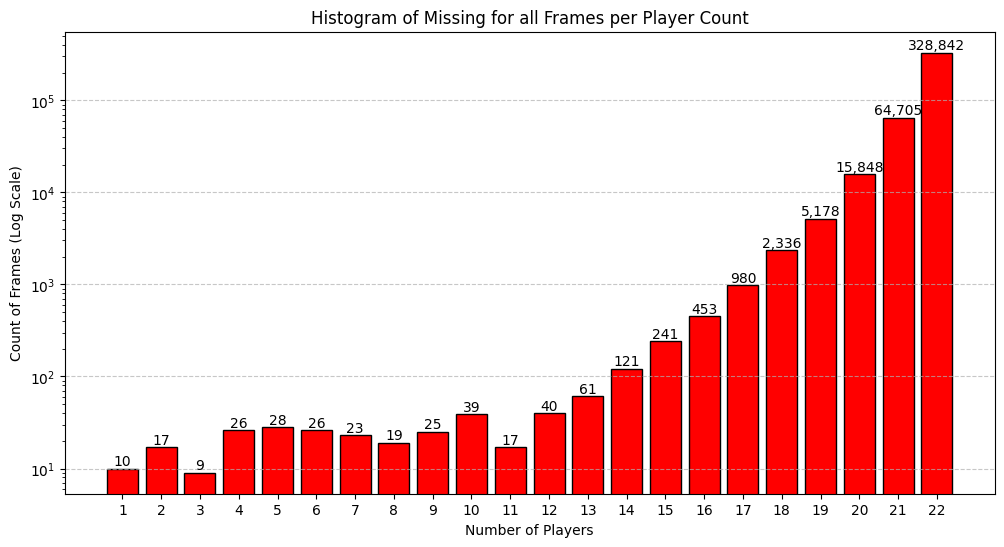

In [14]:
import matplotlib.pyplot as plt

# Create the bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(missing_counts_all.index, missing_counts_all.values, color='red', edgecolor='black')

# Add labels on top of bars
for bar in bars:
    height = bar.get_height()
    if height > 0:  # Only label non-zero bars
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:,}', ha='center', va='bottom', fontsize=10, rotation=0)

# Use logarithmic scale if the difference is too large
plt.yscale('log')

# Labels and title
plt.xlabel('Number of Players')
plt.ylabel('Count of Frames (Log Scale)')
plt.title('Histogram of Missing for all Frames per Player Count')

# Improve x-axis ticks visibility
plt.xticks(range(1, 23))

# Add grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


In [12]:
one_player_frames = frames_player_count[frames_player_count >=21]


In [13]:
one_player_frames.value_counts()

22    53110
21     9698
Name: player, dtype: int64

In [28]:
frames_new_test = frames_new[frames_new["id"] == 1238995789]

In [29]:
frames_new_test

,team_id,team,jersey_number,player,role,speed,x_signality,y_signality,vx_signality,vy_signality,...,pitch_width,team_direction,id,frame,minute,second,period,start_frame,player_id_event,possession_team_id
695843,6710,home_team,20,Nahir Besara,6,1.338,-0.25,-5.90,-0.276190,-0.455556,...,68,right,1238995789,1816,1,13,1,1815.717163,328037,6718
695844,6710,home_team,8,Jeppe Andrup Andersen,7,1.023,-8.89,-10.14,0.196032,-0.356349,...,68,right,1238995789,1816,1,13,1,1815.717163,328037,6718
695845,6710,home_team,6,Darijan Bojanic,8,1.532,-5.65,-17.27,-0.430159,-0.376984,...,68,right,1238995789,1816,1,13,1,1815.717163,328037,6718
695846,6710,home_team,4,Richard Magyar,3,0.659,-17.25,-7.50,0.017460,-0.264286,...,68,right,1238995789,1816,1,13,1,1815.717163,328037,6718
695847,6710,home_team,13,Mads Fenger Nielsen,4,3.097,-14.58,-14.94,0.099206,-1.221429,...,68,right,1238995789,1816,1,13,1,1815.717163,328037,6718
695848,6710,home_team,2,Simon Sandberg,2,1.106,-14.73,1.50,-0.131746,-0.425397,...,68,right,1238995789,1816,1,13,1,1815.717163,328037,6718
695849,6710,home_team,16,Gustav Ludwigson,11,0.619,-3.32,-20.06,0.269048,-0.119048,...,68,right,1238995789,1816,1,13,1,1815.717163,328037,6718
695850,6710,home_team,9,Astrit Selmani,10,3.429,10.61,-14.60,-1.196825,-0.674603,...,68,right,1238995789,1816,1,13,1,1815.717163,328037,6718
695851,6710,home_team,15,Mayckel Lahdo,9,0.582,-0.22,6.98,-0.219048,0.044444,...,68,right,1238995789,1816,1,13,1,1815.717163,328037,6718
695852,6710,home_team,24,Oliver Dovin,1,0.880,-41.57,-2.38,-0.228571,-0.253175,...,68,right,1238995789,1816,1,13,1,1815.717163,328037,6718


In [17]:
frames_player_count.tolist
frames_player_count

id
1238995789    22
1238995794    22
1238995795    22
1238995797    22
1238995799    22
              ..
1462655628    22
1462655629    21
1462655630    22
1462655633    22
1462655655    22
Name: player, Length: 65880, dtype: int64

In [19]:
frames_player_count_new = frames_player_count.reset_index()
frames_player_count_new


,id,player
0,1238995789,22
1,1238995794,22
2,1238995795,22
3,1238995797,22
4,1238995799,22
...,...,...
65875,1462655628,22
65876,1462655629,21
65877,1462655630,22
65878,1462655633,22


In [21]:
frames_player_count_new = frames_player_count_new.rename(columns={'player': 'player_count'})
frames_new_filtered = frames_new.merge(frames_player_count_new, on = 'id')

In [22]:
frames_new_filtered = frames_new_filtered[frames_new_filtered['player_count'] >= 21]

In [23]:
frames_new_filtered['player_count'].value_counts()

22    1168420
21     203658
Name: player_count, dtype: int64

In [ ]:
frames_new_filtered

In [ ]:
frames_new_filtered.to_csv("tracking_2022_final.csv",index=False)

: 

In [58]:
frames_new_filtered[['x_adjusted','y_adjusted']] = frames_new_filtered[['x_adjusted','y_adjusted']].clip(lower=0)
frames_new_filtered

/home/nikitha/anaconda3/envs/thesis/lib/python3.9/site-packages/pandas/core/frame.py:3641: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[k1] = value[k2]


,team_id,team,jersey_number,player,role,speed,x_signality,y_signality,vx_signality,vy_signality,...,team_direction,id,frame,minute,second,period,start_frame,player_id_event,possession_team_id,player_count
0,6769,home_team,21,Abdussalam Magashy,8,7.172,-25.10,2.99,-2.827778,-0.442857,...,left,1256506896,2127,1,28,1,2127.071533,258122,6766,22
1,6769,home_team,9,Oscar Johansson,9,4.395,-27.99,-11.02,-1.685714,-0.458730,...,left,1256506896,2127,1,28,1,2127.071533,258122,6766,22
2,6769,home_team,8,William Kenndal,7,3.048,-11.32,-10.21,-1.215873,-0.194444,...,left,1256506896,2127,1,28,1,2127.071533,258122,6766,22
3,6769,home_team,14,Marcus Antonsson,10,7.108,-35.06,-1.21,-2.850794,-0.294444,...,left,1256506896,2127,1,28,1,2127.071533,258122,6766,22
4,6769,home_team,25,Victor Eriksson,3,2.654,-1.67,0.40,-1.027778,0.273810,...,left,1256506896,2127,1,28,1,2127.071533,258122,6766,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1431104,6711,away_team,1,Ricardo Henrique Schuck Friedrich,1,1.401,-51.90,-0.55,-0.602381,-0.065873,...,right,1368462131,74919,95,0,2,74919.382812,56259,6709,22
1431105,6711,away_team,22,Nahom Girmai Netabay,0,2.067,-39.66,-6.13,-0.787302,0.198413,...,right,1368462131,74919,95,0,2,74919.382812,56259,6709,22
1431106,6711,away_team,10,Filip Sachpekidis,0,1.448,-40.13,4.80,-0.501587,-0.321429,...,right,1368462131,74919,95,0,2,74919.382812,56259,6709,22
1431107,6711,away_team,14,Noah Shamoun,0,1.335,-35.95,6.57,-0.534127,-0.096032,...,right,1368462131,74919,95,0,2,74919.382812,56259,6709,22


In [ ]:
frames_new_filtered.to_csv("frames_new_filtered.csv")